In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [70]:
# System and OS related tasks
import sys
import os

# Add the project root to Python path
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

# path to directories
raw_dir = '../data/raw'
processed_dir = '../data/processed'

# 1.0 Hypothesis Testings

This notebook will cover the following hypothesis testings:
* Hypothesis 1: Climate impact on tea yield
* Hypothesis 2: GDP impact on tea yield
* Hypothesis 3: Crop dominance vs climate

> As this will be a long notebook, it will be sectioned as follows:
>
> * X.0 Hypothesis No 1: 
>
>   * X.1 Preparing the Data
>
>   * X.2 Data Exploration (EDA)
>        * various data visualisation plots 
>
>   * X.3 Statistical Test
>     * t-test output with p-value or chi-square test
>
>   * X.4 Result Visualisation & Conclusion
>     * various data visualisation plots 
>     * Clear statement of what the visualisation and statistical tests mean together
>

# 2.0 Hypothesis No 1: 🌡️ Climate Impact on 🍵 Tea Yield

> ### Hypothesis No. 1
>
> **H<sub>0</sub>**: Mean tea yield is the same in hot or cool climate countries.
>
> **H<sub>1</sub>**: Mean tea yield differs significantly between hot or cool climate countries.
>

## 2.1 Hypothesis No 1: Preparing the Data

📌 Get the main `🍵 tea` data that has `FAO`, `World Bank's GDP` and `World Bank's Climate` data with the granularity of `country-year` for the `top 15 tea producing countries` over the periods of `2000 to 2024`.

In [71]:
filename = "df_main_tea_gdp_climate.csv"

df_main_tea_gdp_climate = pd.read_csv(
    f"{processed_dir}/{filename}",
    )

df_main_tea_gdp_climate.head(5)

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type,Country_Name,GDP_Per_Capita,Temperature,Precipitation,Crop_Dominance
0,ARG,2000,38620.0,323000.0,8363.5,Tea,Argentina,7637.014892,14.45,721.03,tea only
1,ARG,2001,37420.0,309000.0,8257.6,Tea,Argentina,7141.475077,15.08,716.55,tea only
2,ARG,2002,36400.0,306000.0,8406.6,Tea,Argentina,2569.699635,14.84,757.75,tea only
3,ARG,2003,36380.0,304000.0,8356.2,Tea,Argentina,3320.477751,15.23,593.14,tea only
4,ARG,2004,36670.0,306000.0,8344.7,Tea,Argentina,4242.020991,15.24,576.61,tea only


📌 Using the median temperature of these `top 15 tea producing countries` as a criteria for deciding whether a country is in a `Cool` climate or in a `Hot` climate.
* The median temperature is computed based on the 25-year average temperature for each country. 

In [72]:
# calculate the average temperature for each country in a 25-year period
df_avg_temp_by_country = df_main_tea_gdp_climate.groupby("Country_ISO3")["Temperature"].mean().reset_index()
## rename the coloumns
df_avg_temp_by_country.columns = ["Country_ISO3", "Avg_Temp_25yr"]

df_avg_temp_by_country

,Country_ISO3,Avg_Temp_25yr
0,ARG,15.2392
1,BGD,25.7700
2,CHN,7.8312
3,IDN,26.0156
4,IND,25.0488
5,IRN,18.7744
6,JPN,12.0516
7,KEN,25.1412
8,LKA,27.3372
9,MWI,22.7220


📌 Assign hot or cool to each country:

In [73]:
# calculate the median temperature of all the countries 25yr average
tea_country_temp_median = df_avg_temp_by_country["Avg_Temp_25yr"].median()

# make a copy of df_main_tea_gdp_climate
df_main_tea_gdp_climate_zone = df_main_tea_gdp_climate.copy()

df_main_tea_gdp_climate_zone["Climate_Zone"] = df_main_tea_gdp_climate_zone["Temperature"].apply(
    lambda x: "Hot" if x >= tea_country_temp_median else "Cool"
)
print(f"The median temperature in °C is: {tea_country_temp_median}")
print(df_main_tea_gdp_climate_zone["Climate_Zone"].value_counts())
print(df_main_tea_gdp_climate_zone.head(3))

The median temperature in °C is: 22.9248
Climate_Zone
Hot     191
Cool    184
Name: count, dtype: int64
  Country_ISO3  Year  Area_Harvest_Ha  Production_Ton  Yield_Kg_Ha Crop_Type  \
0          ARG  2000          38620.0        323000.0       8363.5       Tea   
1          ARG  2001          37420.0        309000.0       8257.6       Tea   
2          ARG  2002          36400.0        306000.0       8406.6       Tea   

  Country_Name  GDP_Per_Capita  Temperature  Precipitation Crop_Dominance  \
0    Argentina     7637.014892        14.45         721.03       tea only   
1    Argentina     7141.475077        15.08         716.55       tea only   
2    Argentina     2569.699635        14.84         757.75       tea only   

  Climate_Zone  
0         Cool  
1         Cool  
2         Cool  


📌 Double check hot or cool assignment of each country:
* we see that MWI (Malawi) and TZA (Tanbzania) both have "Cool" and "Hot"
* looking at both countries on the map, they both have significant elevation changes.

In [74]:
# check that each country only has 1 climate zone
print(df_main_tea_gdp_climate_zone.groupby("Country_ISO3")["Climate_Zone"].unique())

Country_ISO3
ARG         [Cool]
BGD          [Hot]
CHN         [Cool]
IDN          [Hot]
IND          [Hot]
IRN         [Cool]
JPN         [Cool]
KEN          [Hot]
LKA          [Hot]
MWI    [Cool, Hot]
RWA         [Cool]
TUR         [Cool]
TZA    [Cool, Hot]
UGA          [Hot]
VNM          [Hot]
Name: Climate_Zone, dtype: object


📌 Going into the longitudinal, latitudinal and elevation granularity is beyond the scope of this project.
* As such, 
  * use each country's 25-year average temperature to find the median temperature for all countries in a 25 year period 
  * The country's 25-year average temperature is compared to the median temperature to decide whether a country is in a cool or hot climate.
  * and use that climate zone classification on the df_main_tea_gdp_climate.

In [75]:
# calculate the median temperature of all the countries 25yr average temperatures
tea_country_temp_median = df_avg_temp_by_country["Avg_Temp_25yr"].median()

df_avg_temp_by_country["Climate_Zone"] = df_avg_temp_by_country["Avg_Temp_25yr"].apply(
    lambda x: "Hot" if x >= tea_country_temp_median else "Cool"
)
print(f"The median temperature in °C is: {tea_country_temp_median}")
print(df_avg_temp_by_country.head(15))
print(df_avg_temp_by_country["Climate_Zone"].value_counts())

The median temperature in °C is: 22.9248
   Country_ISO3  Avg_Temp_25yr Climate_Zone
0           ARG        15.2392         Cool
1           BGD        25.7700          Hot
2           CHN         7.8312         Cool
3           IDN        26.0156          Hot
4           IND        25.0488          Hot
5           IRN        18.7744         Cool
6           JPN        12.0516         Cool
7           KEN        25.1412          Hot
8           LKA        27.3372          Hot
9           MWI        22.7220         Cool
10          RWA        19.2808         Cool
11          TUR        12.0696         Cool
12          TZA        22.9248          Hot
13          UGA        23.3640          Hot
14          VNM        24.8792          Hot
Climate_Zone
Hot     8
Cool    7
Name: count, dtype: int64


📌 Now that we have classified a country to a climate_zone. We can apply that to the df_main_tea_gdp_climate as a new dataset df_main_tea_gdp_climate_zone. 

We do a value_count() on the climate_zone column grouped buy country to see that each country is only assign to one climate zone.

In [76]:
# make a copy of df_main_tea_gdp_climate
df_main_tea_gdp_climate_zone = df_main_tea_gdp_climate.copy()

# merge the hot/cool zone column to the df_main_tea_gdp_climate
df_main_tea_gdp_climate_zone = df_main_tea_gdp_climate.merge(
    df_avg_temp_by_country[["Country_ISO3", "Climate_Zone"]]
    , on="Country_ISO3"
    , how="left"
)
df_main_tea_gdp_climate_zone.head(3)
print(df_main_tea_gdp_climate_zone.groupby("Country_ISO3")["Climate_Zone"].unique())

Country_ISO3
ARG    [Cool]
BGD     [Hot]
CHN    [Cool]
IDN     [Hot]
IND     [Hot]
IRN    [Cool]
JPN    [Cool]
KEN     [Hot]
LKA     [Hot]
MWI    [Cool]
RWA    [Cool]
TUR    [Cool]
TZA     [Hot]
UGA     [Hot]
VNM     [Hot]
Name: Climate_Zone, dtype: object


## 2.2 Hypothesis No 1: Data Exploration (EDA)

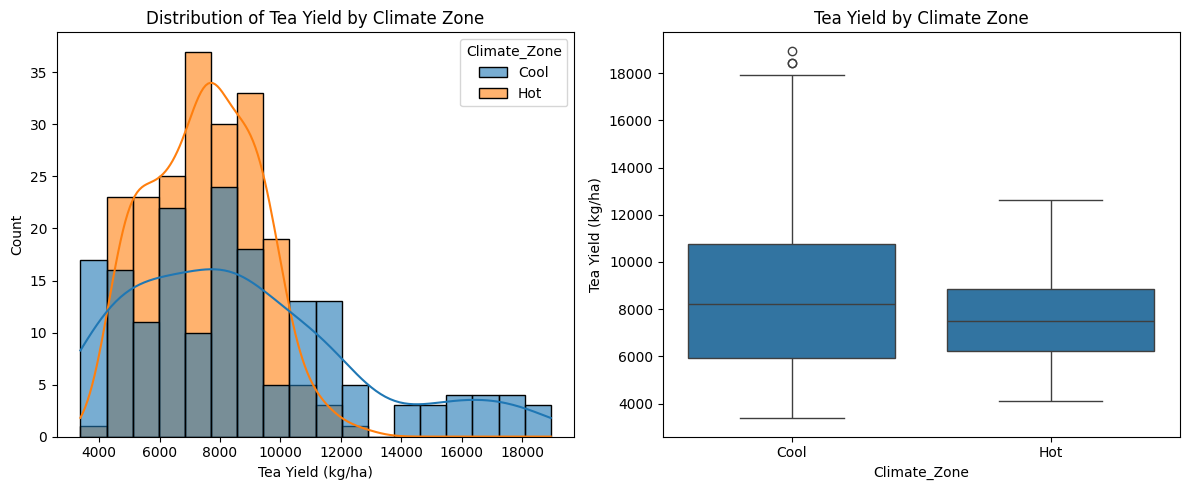

Summary statistics by climate zone:
              count         mean          std     min       25%     50%  \
Climate_Zone                                                              
Cool          175.0  8659.112571  3780.576228  3378.1  5922.450  8226.8   
Hot           200.0  7475.063000  1779.136890  4115.2  6214.825  7498.4   

                    75%      max  
Climate_Zone                      
Cool          10758.100  18948.9  
Hot            8850.425  12620.5  


In [79]:
# Quick EDA: distribution of yield by climate zone
plt.figure(figsize=(12, 5))

# Plot 1: Histogram of yield by climate zone
plt.subplot(1, 2, 1)
sns.histplot(data=df_main_tea_gdp_climate_zone, x='Yield_Kg_Ha', hue='Climate_Zone', kde=True, alpha=0.6)
plt.title('Distribution of Tea Yield by Climate Zone')
plt.xlabel('Tea Yield (kg/ha)')

# Plot 2: Box plot of yield by climate zone
plt.subplot(1, 2, 2)
sns.boxplot(data=df_main_tea_gdp_climate_zone, x='Climate_Zone', y='Yield_Kg_Ha')
plt.title('Tea Yield by Climate Zone')
plt.ylabel('Tea Yield (kg/ha)')

plt.tight_layout()
plt.show()

# Summary statistics by climate zone
print("Summary statistics by climate zone:")
print(df_main_tea_gdp_climate_zone.groupby('Climate_Zone')['Yield_Kg_Ha'].describe())

📌🕵🏻‍♂️ Analysis of the Data Visualizations and Summary Statistics
* the spread of cool and hot observations are around 46% vs 54%. Quite well balanced groups.
* the cool group is slghtly right skewed whilst the hot group is more or less symetrical.
* there appears to be a distinct difference in the means of cool and hot groups which will be tested in our hypothesis later.
* the cool group has a much higher standard deviation than the hot group. 
* the cool group has more outliers and more spread out as compared to the hot group
* the hot group is tighter and has fewer extremes
* the cool group has a higher median than the hot group but the hot group produces more consistently.

> 📌🕵🏻‍♂️ Based on personal experience as trained tea assessor and tea artisan (certified in China), it is expected that any climate with  higher temperature than median temperature of 22.9°C would see a lower yield as the tea plants (in China) as the camellia sinensis tea plant prefers a wider range of temperature variance between day and night which would suggest that the optimal temperature for maximum tea yield would be a lower temperature then then median temperature computed above.

## 2.3 Hypothesis No 1: Statistical Test

We do an independent t-test to see if the difference in yield means between the "cool" group vs the "Hot" group is statistically significant.

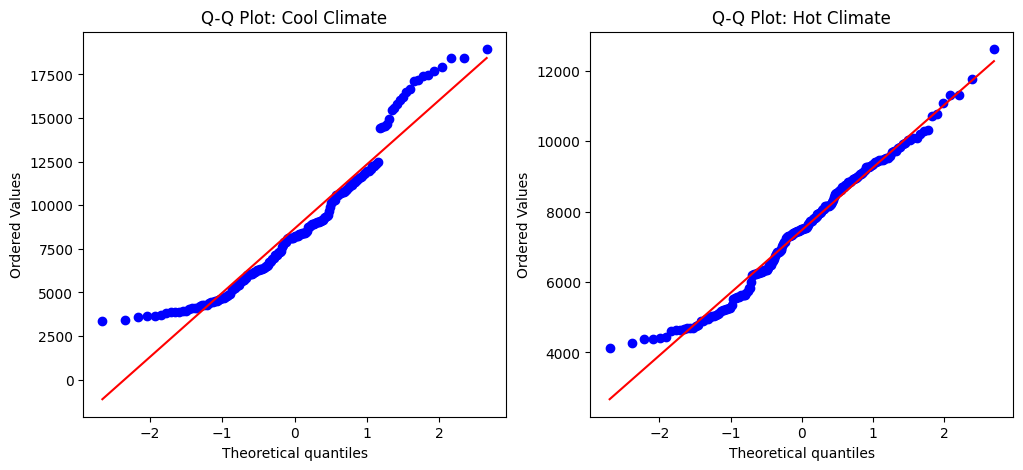

In [82]:
# Split data by climate zone
cool_yield = df_main_tea_gdp_climate_zone[df_main_tea_gdp_climate_zone['Climate_Zone'] == 'Cool']['Yield_Kg_Ha']
hot_yield = df_main_tea_gdp_climate_zone[df_main_tea_gdp_climate_zone['Climate_Zone'] == 'Hot']['Yield_Kg_Ha']

# Q-Q plots to check normality
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(cool_yield, dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot: Cool Climate')
stats.probplot(hot_yield, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot: Hot Climate')
plt.show()

The QQ plots on the Cool and Hot climate would suggest the the data is sufficently normal for the parametric t-test,

In [86]:
# Split data by climate zone
cool_yield = df_main_tea_gdp_climate_zone[df_main_tea_gdp_climate_zone['Climate_Zone'] == 'Cool']['Yield_Kg_Ha']
hot_yield = df_main_tea_gdp_climate_zone[df_main_tea_gdp_climate_zone['Climate_Zone'] == 'Hot']['Yield_Kg_Ha']

# Independent t-test
t_stat, p_value = stats.ttest_ind(cool_yield, hot_yield)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Reject H₀: Tea yield differs significantly between climate zones")
else:
    print("❌ Fail to reject H₀: No significant difference detected")

T-statistic: 3.957
P-value: 0.0001
✅ Reject H₀: Tea yield differs significantly between climate zones


## 2.4 Hypothesis No 1: Result Visualisation & Conclusion

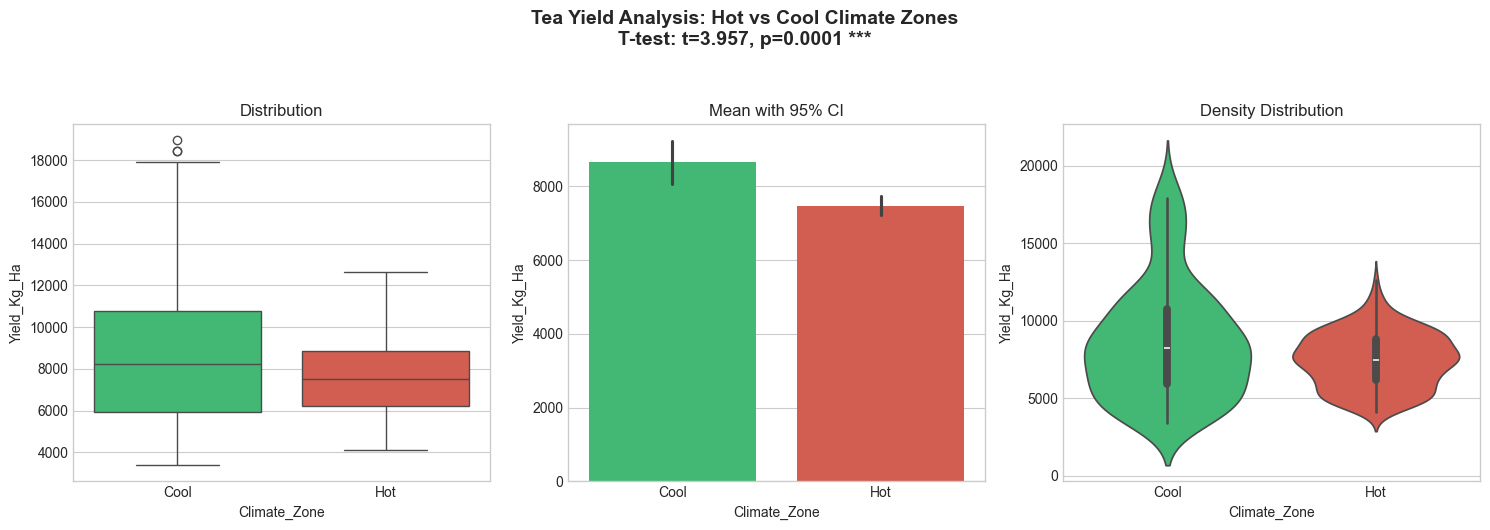


📊 T-Test Results:
   t-statistic: 3.957
   p-value: 0.0001
   Significance: ***
   Interpretation: Reject H₀


In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Calculate t-test results
cool = df_main_tea_gdp_climate_zone[df_main_tea_gdp_climate_zone['Climate_Zone'] == 'Cool']['Yield_Kg_Ha']
hot = df_main_tea_gdp_climate_zone[df_main_tea_gdp_climate_zone['Climate_Zone'] == 'Hot']['Yield_Kg_Ha']
t_stat, p_value = stats.ttest_ind(cool, hot)

# Create significance stars
if p_value < 0.001:
    sig_stars = "***"
elif p_value < 0.01:
    sig_stars = "**"
elif p_value < 0.05:
    sig_stars = "*"
else:
    sig_stars = "ns"

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Box plot
sns.boxplot(x='Climate_Zone', y='Yield_Kg_Ha', data=df_main_tea_gdp_climate_zone, ax=axes[0],
            palette=['#2ecc71', '#e74c3c'], hue='Climate_Zone', legend=False)
axes[0].set_title('Distribution', fontsize=12)

# Plot 2: Mean with error bars
sns.barplot(x='Climate_Zone', y='Yield_Kg_Ha', data=df_main_tea_gdp_climate_zone, 
            ax=axes[1], errorbar=('ci', 95), 
            palette=['#2ecc71', '#e74c3c'], hue='Climate_Zone', legend=False)
axes[1].set_title('Mean with 95% CI', fontsize=12)

# Plot 3: Violin plot
sns.violinplot(x='Climate_Zone', y='Yield_Kg_Ha', data=df_main_tea_gdp_climate_zone, 
               ax=axes[2], palette=['#2ecc71', '#e74c3c'], hue='Climate_Zone', legend=False)
axes[2].set_title('Density Distribution', fontsize=12)

# Add overall title with stats
plt.suptitle(f'Tea Yield Analysis: Hot vs Cool Climate Zones\n'
             f'T-test: t={t_stat:.3f}, p={p_value:.4f} {sig_stars}',
             fontsize=14, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

# Print interpretation
print(f"\n📊 T-Test Results:")
print(f"   t-statistic: {t_stat:.3f}")
print(f"   p-value: {p_value:.4f}")
print(f"   Significance: {sig_stars}")
print(f"   Interpretation: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")

"The t-test confirms that this difference is [significant/not significant] (p = X.XXX). Cool climate countries achieve [X] kg/ha higher yields on average, but with nearly double the variability, suggesting a trade-off between potential and consistency."

---

# 3.0 Hypothesis No 2: 💵 GDP Impact on 🍵 Tea Yield

> ### Hypothesis No. 2
>
> **H<sub>0</sub>**: ??
>
> **H<sub>1</sub>**: ??
>

## 3.1 Hypothesis No 2: Preparing the data

## 3.2 Hypothesis No 2: Data Exploration (EDA)

## 3.3 Hypothesis No 2: Statistical Test

## 3.4 Hypothesis No 2: Result Visualisation & Conclusion

---

# 4.0 Hypothesis No 3: Crop Dominance vs Climate

> ### Hypothesis No. 3
>
> **H<sub>0</sub>**: ??
>
> **H<sub>1</sub>**: ??
>

## 4.1 Hypothesis No 3: Prepare the Data

## 4.2 Hypothesis No 3: Data Exploration (EDA)

## 4.3 Hypothesis No 3: Statistical Test

## 4.4 Hypothesis No 3: Result Visualisation & Conclusion

---